 In this notebook, we want to investigate expected batting average (xBA) and how it is modeled by statcast.  Statcast does provide their estimate, so we can use that as a baseline.  Primarily we will explore this vs exit velocity and launch angle.

In [87]:
from pipeline.db import get_client
import polars as pl
import numpy as np
client = get_client()

## Pull in raw data

In [41]:
df = pl.from_arrow(client.query_arrow(
     """
SELECT
  launch_speed,
  launch_angle,
    game_year,
    estimated_ba_using_speedangle,
  events,
  events IN ('single', 'double', 'triple', 'home_run') AS is_hit
FROM pitches
WHERE launch_speed IS NOT NULL
AND launch_angle IS NOT NULL
AND events IS NOT NULL
AND estimated_ba_using_speedangle IS NOT NULL
"""
 )
 )
df.shape

(683153, 6)

In [70]:
df.sort(by="estimated_ba_using_speedangle", descending=True).head(5)

launch_speed,launch_angle,game_year,estimated_ba_using_speedangle,events,is_hit
f32,f32,u16,f32,str,u8
110.900002,28.0,2020,1.0,"""home_run""",1
109.199997,26.0,2020,1.0,"""home_run""",1
112.0,28.0,2020,1.0,"""home_run""",1
109.300003,26.0,2020,1.0,"""home_run""",1
110.199997,25.0,2020,1.0,"""home_run""",1


## Approach 1: Modeling

I have seen that statcast says it uses Exit Velocity (EV) and Launch Angle (LA) as their inputs to calculating things like expected Batting Average.  This is also evident from how they named their "estimated_ba_using_speedangle" field.  Let's see if we can get similar results

A couple of things we can look at
- model.score : This will tell us the accuracy (how many times did we predict correctly).  Not a great metric
- Correlation and MAE compared "estimated_ba_using_speedangle" - this tells us how close we are to reverse engineering their model.

To start off, we will use 2025 as testing and everything before that as training.

In [86]:
from sklearn.metrics import mean_absolute_error

train = df.filter(pl.col("game_year") < 2025)
test = df.filter(pl.col("game_year") == 2025)
def compare_performance(model, test_input):
    """Metrics for comparing a model to statcast"""
    statcast_ba = test.select("estimated_ba_using_speedangle").to_numpy().ravel()
    true_hit = test.select(pl.col("is_hit")).to_numpy().ravel()
    xba_predicted = model.predict_proba(test_input)[:, 1]

    print(f"Model Accuracy: {model.score(test_input, true_hit):.4f}")
    print(f"MAE vs Statcast: {mean_absolute_error(statcast_ba, xba_predicted):.4f}")
    print(f"Correlation with Statcast: {np.corrcoef(statcast_ba, xba_predicted)[0,1]:.4f}")


## Basic Logistic Regression

No hyperparameter tuning

In [83]:
from sklearn.linear_model import LogisticRegression

y_train = train.select(pl.col("is_hit")).to_numpy().ravel()
y_test = test.select(pl.col("is_hit")).to_numpy().ravel()
X_train = train.select(
    [pl.col("launch_speed"), pl.col("launch_angle")]
).to_numpy()
X_test = test.select(
    [pl.col("launch_speed"), pl.col("launch_angle")]
).to_numpy()

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

compare_performance(logreg, X_test)


Model Accuracy: 0.6902
MAE vs Statcast: 0.2086
Correlation with Statcast: 0.4339


~70% accuracy is basically consistent with us saying everything is an out (since a high approximation of a batting average is .300, guessing out for everything will be 70% accurate, 75% accurate these days).  Low correlation with Statcast, so more information is included for there modeling (or a better model).

We can try adding polynomial terms to see if there are any interactions:

In [85]:
# Add polynomial features
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)


logreg2 = LogisticRegression(max_iter=1000, C=.5)
logreg2.fit(X_train_poly, y_train)
compare_performance(logreg2, X_test_poly)



Model Accuracy: 0.7446
MAE vs Statcast: 0.1553
Correlation with Statcast: 0.6965


So adding the interaction moves the needle a bit.  As mentioned, accuracy is not a great metric for evaluating, but we see we are closer to the provided data.  We could try to get more creative, but let's move to a gradient boosted model since that can capture non-linear between the input fields without specifically crafted interaction terms.

In [89]:
from sklearn.ensemble import GradientBoostingClassifier

gbc = GradientBoostingClassifier(random_state=99) # For Judge
gbc.fit(X_train, y_train)
compare_performance(gbc, X_test)


Model Accuracy: 0.8003
MAE vs Statcast: 0.0556
Correlation with Statcast: 0.9581


Wowza.  Gradient Booster out of the box, no tuning gets us 80% accuracy and a >.95 correlation.  We can probably move to a HistGradientBoostingClassifier for faster performance and exploring fine tuning models.

In [98]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_boost = HistGradientBoostingClassifier(random_state=99)
hist_boost.fit(X_train, y_train)
compare_performance(hist_boost, X_test)

Model Accuracy: 0.8066
MAE vs Statcast: 0.0305
Correlation with Statcast: 0.9868


Or we just use that out of the box.  Correlation of ~.99.  I was going to go through a fun exercise of fine tuning, but damn I would just be grasping for straws.  I am very confident that this is a simplification of the model they use.  I imagine we could add some information about spray angle to squeeze some extra, ie 100 mph right up the middle is different than 100 mph right to the SS, but I don't want to dive that deep.

# Explore expected BA over EV/LA range

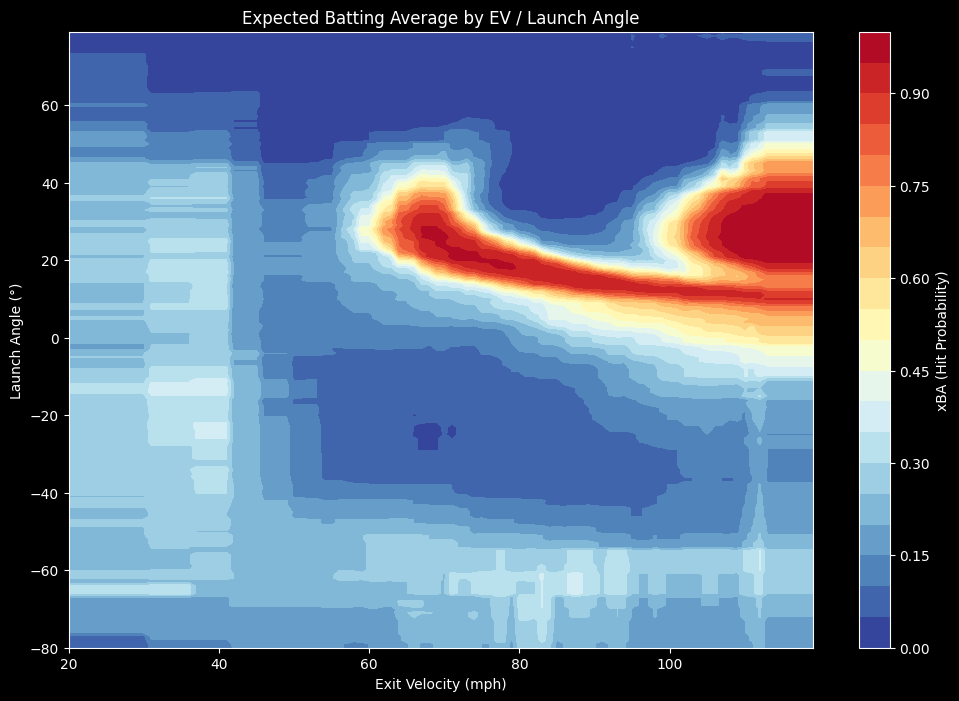

In [102]:
import matplotlib.pyplot as plt

ev_range = np.arange(20, 120, 1)
la_range = np.arange(-80, 80, 1)
ev_grid, la_grid = np.meshgrid(ev_range, la_range)

X_grid = np.column_stack([ev_grid.ravel(), la_grid.ravel()])
probs = hist_boost.predict_proba(X_grid)[:, 1].reshape(ev_grid.shape)

plt.figure(figsize=(12, 8))
plt.contourf(ev_grid, la_grid, probs, levels=20, cmap="RdYlBu_r")
plt.colorbar(label="xBA (Hit Probability)")
plt.xlabel("Exit Velocity (mph)")
plt.ylabel("Launch Angle (°)")
plt.title("Expected Batting Average by EV / Launch Angle")
plt.show()
